# Fake News Classifier - DD.V3
### Complete Pipeline: Classical ML + NN + BERT Embeddings + Ensemble

**Workflow:**
1. Imports
2. Load data
3. Train / Validation / Test Split
4. Preprocessing (Classical ML)
5. Feature Extraction (TF-IDF + BOW)
6. Classical ML Models (LR, NB, RF, XGB)
7. Cross Validation
8. Classical ML Visualisation
9. BERT Preprocessing and Embeddings
10. Neural Network (NN + BERT)
11. BERT Visualisation
12. Ensemble (LR/BOW + NN/BERT) (Best model)
13. Predictions on new data
14. Gradio Demo App

## STEP 1 - Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import string
import random
import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# BERT / Neural Network imports
from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("Setup ready!")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup ready!


## STEP 2 - Load Data

In [2]:
df = pd.read_csv("/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/TEST:W4_project_NLP/training_data_lowercase.csv")
df.fillna("", inplace=True)

print("Shape:", df.shape)
print("Empty values:", df.isnull().sum().to_dict())
print("Class distribution:")
print(df["label"].value_counts())
df.head()

Shape: (34152, 2)
Empty values: {'label': 0, 'text': 0}
Class distribution:
label
0    17572
1    16580
Name: count, dtype: int64


,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


## STEP 3 - Train / Validation / Test Split
**Important:** Split BEFORE preprocessing so test and validation data remain truly unseen!



In [3]:
# Step 1: split into train (80%) and test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

# Step 2: split train further into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f"Train:      {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(df)*100:.0f}%)")
print(f"Test:       {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)")

Train:      21856 samples (64%)
Validation: 5465 samples (16%)
Test:       6831 samples (20%)


## STEP 4 - Preprocessing (Classical ML)
Data is already lowercase, no HTML present.
Steps: special chars → tokenization → stopwords → lemmatization

**Note:** BERT uses a different, minimal preprocessing (Step 9)

In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    # Remove single characters and double spaces
    text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    # Tokenization - must be before stopwords and lemmatization!
    tokens = word_tokenize(text)
    # Stopwords removal - must be after lowercase!
    tokens = [w for w in tokens if w not in stop_words]
    # Lemmatization - must be before feature extraction!
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# Apply separately on train, validation and test - NEVER fit on test!
X_train = X_train.apply(preprocess)
X_val   = X_val.apply(preprocess)
X_test  = X_test.apply(preprocess)

# Visual check before vs after preprocessing
print("BEFORE:", df["text"].loc[X_train.index[1]])
print("AFTER: ", X_train.values[1])

BEFORE: harvey weinstein rape accuser has warrant issued for her arrest‚coincidence?
AFTER:  harvey weinstein rape accuser warrant issued arrest coincidence


## STEP 5 - Feature Extraction
**fit_transform on train only** → learns vocabulary
**transform on validation and test** → uses SAME vocabulary, NEVER fit_transform on test data!

In [5]:
# TF-IDF vectorizer - weights rare words higher
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

# BOW vectorizer - counts word occurrences
cv = CountVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_bow = cv.fit_transform(X_train)
X_val_bow   = cv.transform(X_val)
X_test_bow  = cv.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)
print("BOW shape:   ", X_train_bow.shape)

TF-IDF shape: (21856, 20000)
BOW shape:    (21856, 20000)


## STEP 6 - Classical ML Models
All models trained and evaluated on train, validation and test with Accuracy and F1 score.

In [6]:
models = {
    "LR + TF-IDF":  (LogisticRegression(max_iter=1000),                                       X_train_tfidf, X_val_tfidf, X_test_tfidf),
    "NB + TF-IDF":  (MultinomialNB(),                                                          X_train_tfidf, X_val_tfidf, X_test_tfidf),
    "LR + BOW":     (LogisticRegression(max_iter=1000),                                       X_train_bow,   X_val_bow,   X_test_bow),
    "NB + BOW":     (MultinomialNB(),                                                          X_train_bow,   X_val_bow,   X_test_bow),
    "RF + TF-IDF":  (RandomForestClassifier(n_estimators=100, random_state=42),               X_train_tfidf, X_val_tfidf, X_test_tfidf),
    "RF + BOW":     (RandomForestClassifier(n_estimators=100, random_state=42),               X_train_bow,   X_val_bow,   X_test_bow),
    "XGB + TF-IDF": (XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss"), X_train_tfidf, X_val_tfidf, X_test_tfidf),
    "XGB + BOW":    (XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss"), X_train_bow,   X_val_bow,   X_test_bow),
}

results        = {}
trained_models = {}

print("{:<15} {:>8} {:>8} {:>8} {:>8} {:>8} {:>8} {:>8}".format(
    "Model", "Tr Acc", "Val Acc", "Te Acc", "Tr F1", "Val F1", "Te F1", "Overfit"))
print("-" * 80)

for name, (model, X_tr, X_v, X_te) in models.items():
    model.fit(X_tr, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_tr))
    val_acc   = accuracy_score(y_val,   model.predict(X_v))
    test_acc  = accuracy_score(y_test,  model.predict(X_te))
    train_f1  = f1_score(y_train,       model.predict(X_tr))
    val_f1    = f1_score(y_val,         model.predict(X_v))
    test_f1   = f1_score(y_test,        model.predict(X_te))
    overfit   = abs(train_acc - test_acc)
    results[name]        = (train_acc, val_acc, test_acc, train_f1, val_f1, test_f1)
    trained_models[name] = model
    print("{:<15} {:>8.3f} {:>8.3f} {:>8.3f} {:>8.3f} {:>8.3f} {:>8.3f} {:>8.3f}".format(
        name, train_acc, val_acc, test_acc, train_f1, val_f1, test_f1, overfit))

Model             Tr Acc  Val Acc   Te Acc    Tr F1   Val F1    Te F1  Overfit
--------------------------------------------------------------------------------
LR + TF-IDF        0.960    0.933    0.932    0.959    0.932    0.930    0.028
NB + TF-IDF        0.955    0.935    0.928    0.954    0.933    0.926    0.027
LR + BOW           0.985    0.937    0.937    0.985    0.935    0.935    0.048
NB + BOW           0.954    0.934    0.932    0.953    0.932    0.929    0.023
RF + TF-IDF        1.000    0.908    0.910    1.000    0.905    0.908    0.090
RF + BOW           1.000    0.907    0.910    1.000    0.903    0.906    0.090
XGB + TF-IDF       0.912    0.883    0.882    0.913    0.887    0.885    0.030
XGB + BOW          0.896    0.881    0.879    0.899    0.884    0.882    0.016


## STEP 7 - Cross Validation
Confirms that scores are reliable and not dependent on one specific split.

In [7]:
models_cv = {
    "LR + TF-IDF": (LogisticRegression(max_iter=1000), X_train_tfidf),
    "NB + TF-IDF": (MultinomialNB(),                   X_train_tfidf),
    "LR + BOW":    (LogisticRegression(max_iter=1000), X_train_bow),
    "NB + BOW":    (MultinomialNB(),                   X_train_bow),
}

print("{:<15} {:>15} {:>8} {}".format("Model", "CV Average", "Std", "Scores"))
print("-" * 65)

for name, (model, X_tr) in models_cv.items():
    scores = cross_val_score(model, X_tr, y_train, cv=5, scoring="accuracy")
    print("{:<15} {:>15.3f} {:>8.3f}   {}".format(name, scores.mean(), scores.std(), scores.round(3)))

Model                CV Average      Std Scores
-----------------------------------------------------------------
LR + TF-IDF               0.928    0.003   [0.933 0.929 0.925 0.926 0.929]
NB + TF-IDF               0.928    0.003   [0.931 0.925 0.925 0.929 0.931]
LR + BOW                  0.931    0.002   [0.933 0.931 0.929 0.932 0.93 ]
NB + BOW                  0.930    0.003   [0.933 0.929 0.925 0.932 0.932]


## STEP 8 - Classical ML Visualisation

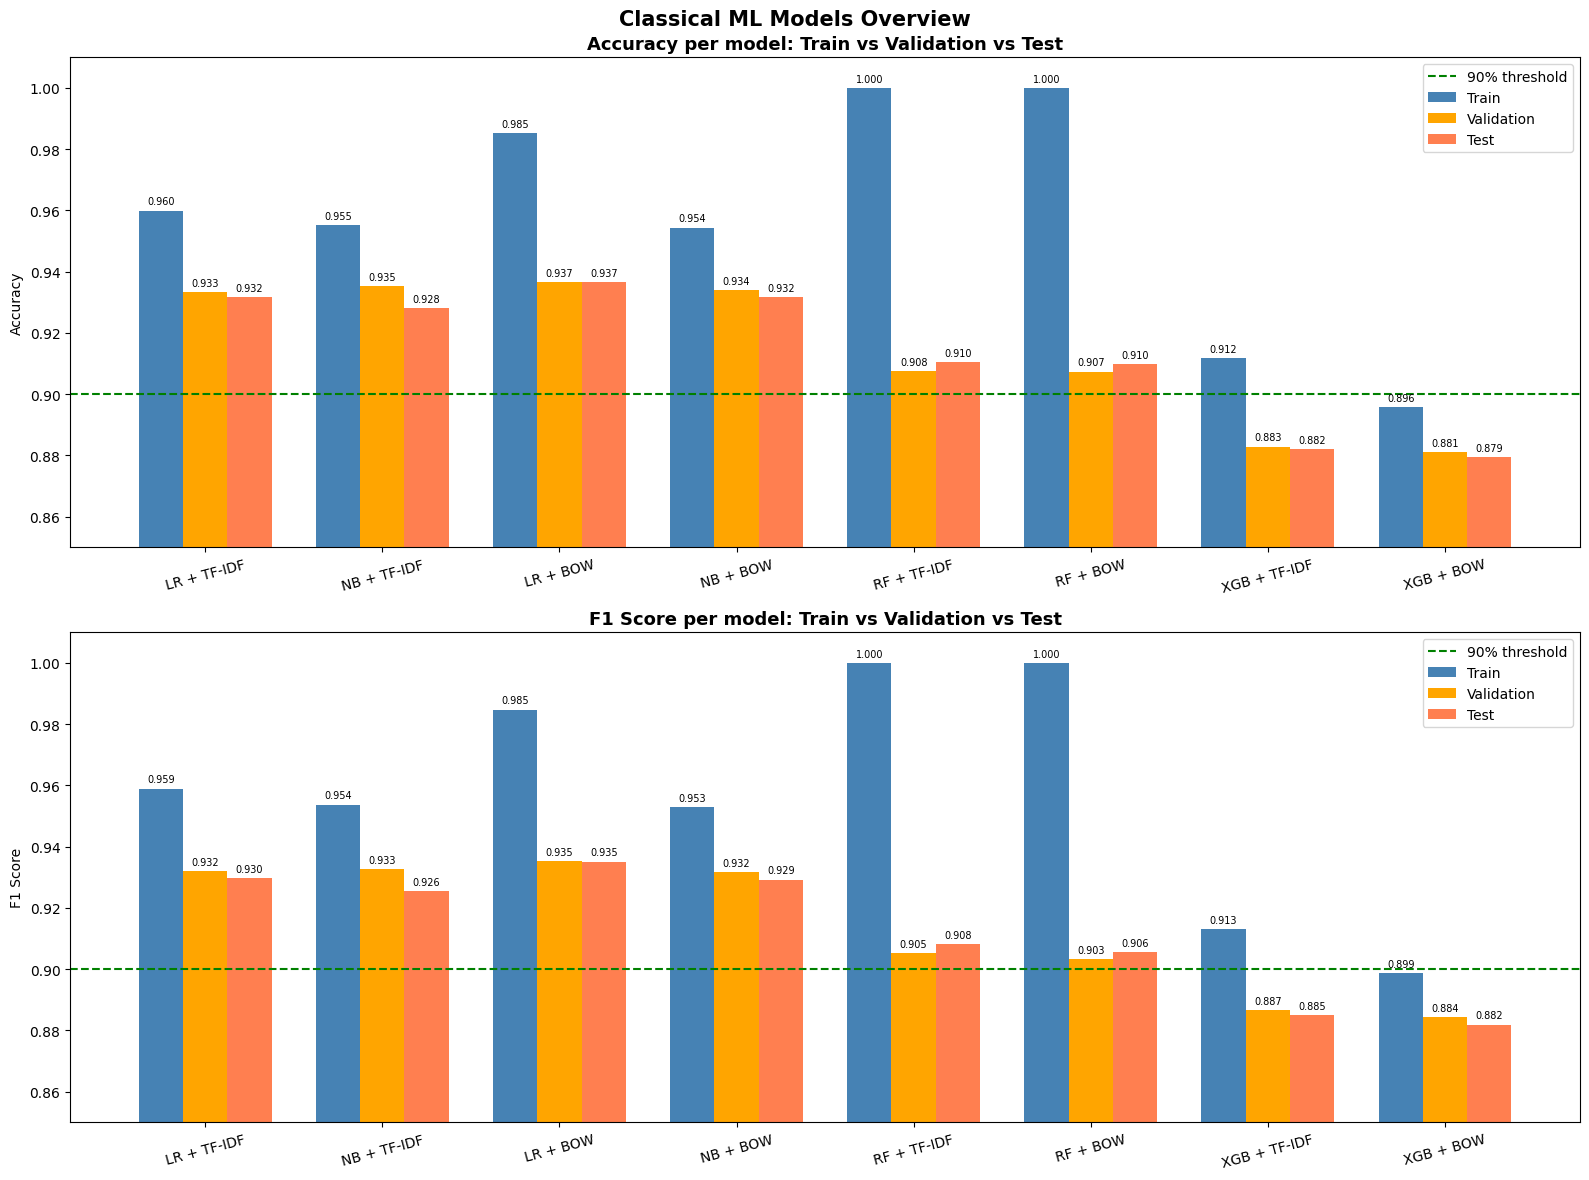

In [8]:
namen      = list(results.keys())
n_modellen = len(namen)
x          = np.arange(n_modellen)
breedte    = 0.25

train_accs = [v[0] for v in results.values()]
val_accs   = [v[1] for v in results.values()]
test_accs  = [v[2] for v in results.values()]
train_f1s  = [v[3] for v in results.values()]
val_f1s    = [v[4] for v in results.values()]
test_f1s   = [v[5] for v in results.values()]

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Accuracy plot
axes[0].bar(x - breedte, train_accs, breedte, label="Train",      color="steelblue")
axes[0].bar(x,           val_accs,   breedte, label="Validation", color="orange")
axes[0].bar(x + breedte, test_accs,  breedte, label="Test",       color="coral")
axes[0].set_title("Accuracy per model: Train vs Validation vs Test", fontsize=13, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(namen, rotation=15)
axes[0].set_ylim(0.85, 1.01)
axes[0].set_ylabel("Accuracy")
axes[0].axhline(y=0.9, color="green", linestyle="--", label="90% threshold")
for i, (tr, va, te) in enumerate(zip(train_accs, val_accs, test_accs)):
    axes[0].text(i - breedte, tr + 0.002, f"{tr:.3f}", ha="center", fontsize=7)
    axes[0].text(i,           va + 0.002, f"{va:.3f}", ha="center", fontsize=7)
    axes[0].text(i + breedte, te + 0.002, f"{te:.3f}", ha="center", fontsize=7)
axes[0].legend()

# F1 plot
axes[1].bar(x - breedte, train_f1s, breedte, label="Train",      color="steelblue")
axes[1].bar(x,           val_f1s,   breedte, label="Validation", color="orange")
axes[1].bar(x + breedte, test_f1s,  breedte, label="Test",       color="coral")
axes[1].set_title("F1 Score per model: Train vs Validation vs Test", fontsize=13, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(namen, rotation=15)
axes[1].set_ylim(0.85, 1.01)
axes[1].set_ylabel("F1 Score")
axes[1].axhline(y=0.9, color="green", linestyle="--", label="90% threshold")
for i, (tr, va, te) in enumerate(zip(train_f1s, val_f1s, test_f1s)):
    axes[1].text(i - breedte, tr + 0.002, f"{tr:.3f}", ha="center", fontsize=7)
    axes[1].text(i,           va + 0.002, f"{va:.3f}", ha="center", fontsize=7)
    axes[1].text(i + breedte, te + 0.002, f"{te:.3f}", ha="center", fontsize=7)
axes[1].legend()

plt.suptitle("Classical ML Models Overview", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

=== Classification Report: LR + BOW ===
              precision    recall  f1-score   support

    Fake (0)       0.95      0.93      0.94      3529
    Real (1)       0.93      0.94      0.94      3302

    accuracy                           0.94      6831
   macro avg       0.94      0.94      0.94      6831
weighted avg       0.94      0.94      0.94      6831



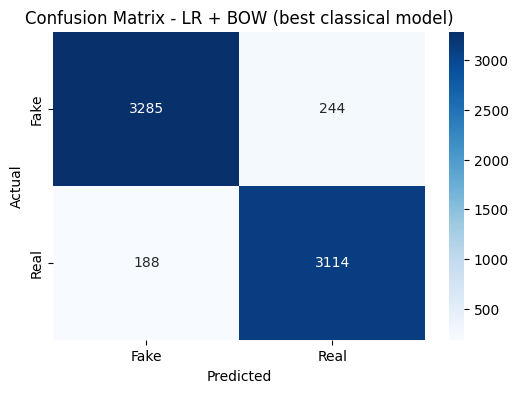

In [9]:
# Classification report and confusion matrix for best classical model (LR + BOW)
best_model  = trained_models["LR + BOW"]
y_pred_best = best_model.predict(X_test_bow)

print("=== Classification Report: LR + BOW ===")
print(classification_report(y_test, y_pred_best, target_names=["Fake (0)", "Real (1)"]))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.title("Confusion Matrix - LR + BOW (best classical model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## STEP 9 - BERT Preprocessing and Embeddings
**Minimal preprocessing for BERT** - no stopwords, no lemmatization!
BERT understands context itself - removing stopwords would hurt performance.

We use the original unseen text (from df) not the already cleaned X_train.

In [10]:
def preprocess_bert(text):
    # Only lowercase and remove extra spaces
    # No stopwords - BERT needs them for context!
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Use original text from df (not the already cleaned X_train)
# Same indices = same split = same random_state = fair comparison
X_train_bert = df.loc[X_train.index, "text"].apply(preprocess_bert)
X_val_bert   = df.loc[X_val.index,   "text"].apply(preprocess_bert)
X_test_bert  = df.loc[X_test.index,  "text"].apply(preprocess_bert)

print(f"Train: {X_train_bert.shape[0]} | Val: {X_val_bert.shape[0]} | Test: {X_test_bert.shape[0]}")
print("Example:", X_train_bert.values[0])

# Calculate BERT Embeddings - converts each sentence to a vector of 384 numbers
# device=mps uses Apple Silicon GPU for faster processing
model_st = SentenceTransformer("all-MiniLM-L6-v2", device="mps")

print("Calculating embeddings...")
X_train_emb = model_st.encode(X_train_bert.tolist(), show_progress_bar=True)
X_val_emb   = model_st.encode(X_val_bert.tolist(),   show_progress_bar=True)
X_test_emb  = model_st.encode(X_test_bert.tolist(),  show_progress_bar=True)

print("Shape embeddings:", X_train_emb.shape)  # (21856, 384)

Train: 21856 | Val: 5465 | Test: 6831
Example: merkel admits mistakes in the 2016 christmas market attack


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9177.52it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating embeddings...


Batches: 100%|██████████| 214/214 [00:03<00:00, 57.64it/s]

Shape embeddings: (21856, 384)


## STEP 10 - Neural Network (NN + BERT)
**Architecture:**
- Input: 384 BERT embedding dimensions
- Dense layers: 256 → 128 → 64 → 1
- BatchNormalization: stabilizes training
- Dropout: prevents overfitting
- Output: sigmoid → probability between 0 and 1

In [11]:
model_nn_bert = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_emb.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),  # randomly disables 30% of neurons to prevent overfitting
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")  # output: probability between 0 and 1
])

model_nn_bert.compile(
    optimizer="adam",
    loss="binary_crossentropy",  # for binary classification (fake/real)
    metrics=["accuracy"]
)

# EarlyStopping: stops training when val_loss stops improving
# restore_best_weights: uses the best epoch weights, not the last
early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

model_nn_bert.summary()

history = model_nn_bert.fit(
    X_train_emb, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_emb, y_val),
    callbacks=[early_stop]
)

# Evaluation
y_train_pred_bert = (model_nn_bert.predict(X_train_emb) > 0.5).astype(int)
y_val_pred_bert   = (model_nn_bert.predict(X_val_emb)   > 0.5).astype(int)
y_test_pred_bert  = (model_nn_bert.predict(X_test_emb)  > 0.5).astype(int)

bert_train_acc = accuracy_score(y_train, y_train_pred_bert)
bert_val_acc   = accuracy_score(y_val,   y_val_pred_bert)
bert_test_acc  = accuracy_score(y_test,  y_test_pred_bert)
bert_train_f1  = f1_score(y_train,       y_train_pred_bert)
bert_val_f1    = f1_score(y_val,         y_val_pred_bert)
bert_test_f1   = f1_score(y_test,        y_test_pred_bert)

print("\nNN + BERT Embeddings:")
print(f"Train → Acc: {bert_train_acc:.3f} | F1: {bert_train_f1:.3f}")
print(f"Val   → Acc: {bert_val_acc:.3f}   | F1: {bert_val_f1:.3f}")
print(f"Test  → Acc: {bert_test_acc:.3f}  | F1: {bert_test_f1:.3f}")

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,313 (552.00 KB)

 Trainable params: 140,545 (549.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8833 - loss: 0.2768 - val_accuracy: 0.9292 - val_loss: 0.1775
Epoch 2/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9208 - loss: 0.1991 - val_accuracy: 0.9327 - val_loss: 0.1636
Epoch 3/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9333 - loss: 0.1680 - val_accuracy: 0.9363 - val_loss: 0.1603
Epoch 4/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9393 - loss: 0.1542 - val_accuracy: 0.9400 - val_loss: 0.1458
Epoch 5/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9465 - loss: 0.1369 - val_accuracy: 0.9422 - val_loss: 0.1500
Epoch 6/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9530 - loss: 0.1198 - val_accuracy: 0.9425 - val_loss: 0.1482
683/683 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step

NN + BERT Embeddings:
Train → Acc: 0.969 | F1: 0.968
Val   → Acc: 0.940   | F1: 0.939
Test  → Acc: 0.9

## STEP 11 - BERT Visualisation

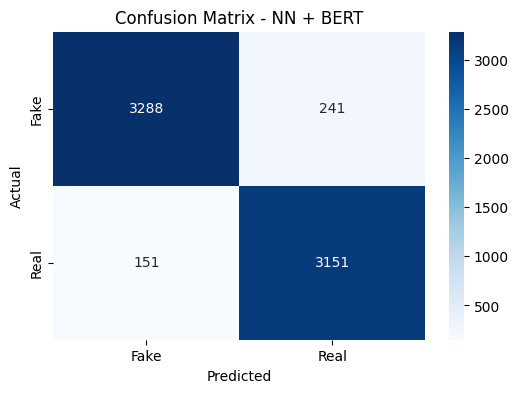

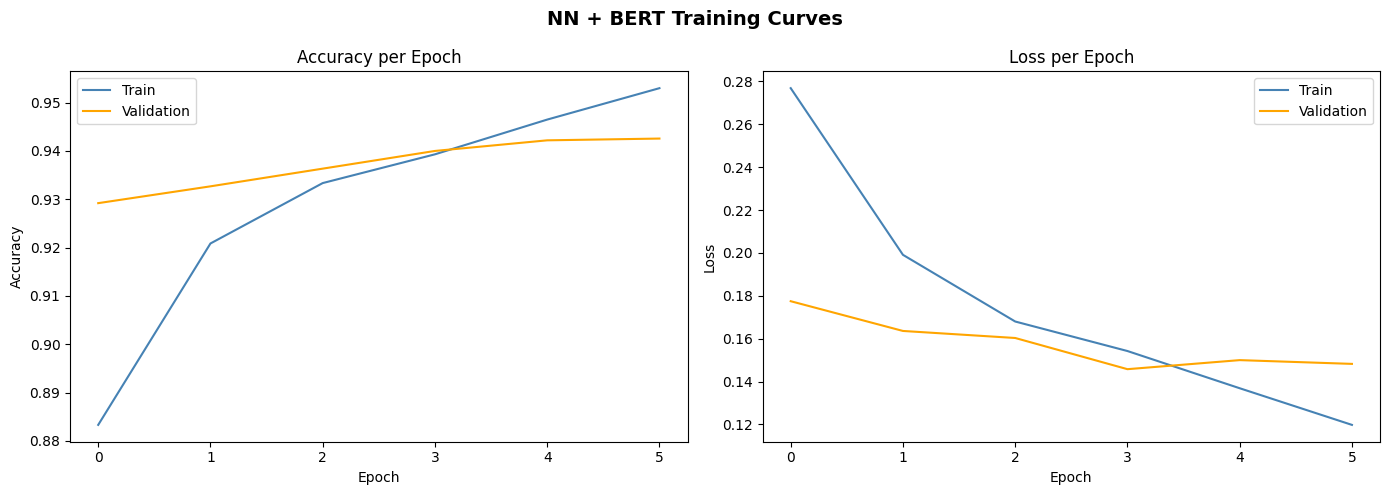

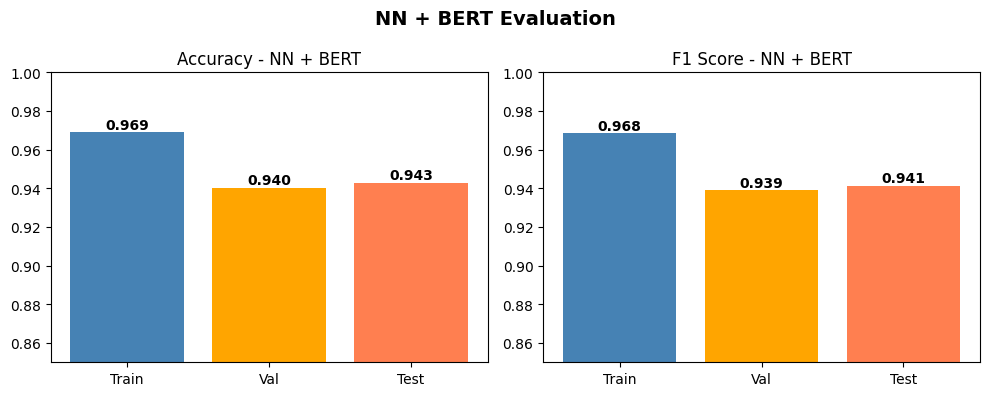

In [12]:
# Confusion Matrix NN + BERT
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred_bert), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.title("Confusion Matrix - NN + BERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Training curves - shows if model is overfitting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train",      color="steelblue")
axes[0].plot(history.history["val_accuracy"], label="Validation", color="orange")
axes[0].set_title("Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train",      color="steelblue")
axes[1].plot(history.history["val_loss"], label="Validation", color="orange")
axes[1].set_title("Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("NN + BERT Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Train / Val / Test bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Train", "Val", "Test"], [bert_train_acc, bert_val_acc, bert_test_acc], color=["steelblue", "orange", "coral"])
axes[0].set_title("Accuracy - NN + BERT")
axes[0].set_ylim(0.85, 1.0)
for i, v in enumerate([bert_train_acc, bert_val_acc, bert_test_acc]):
    axes[0].text(i, v + 0.002, f"{v:.3f}", ha="center", fontweight="bold")

axes[1].bar(["Train", "Val", "Test"], [bert_train_f1, bert_val_f1, bert_test_f1], color=["steelblue", "orange", "coral"])
axes[1].set_title("F1 Score - NN + BERT")
axes[1].set_ylim(0.85, 1.0)
for i, v in enumerate([bert_train_f1, bert_val_f1, bert_test_f1]):
    axes[1].text(i, v + 0.002, f"{v:.3f}", ha="center", fontweight="bold")

plt.suptitle("NN + BERT Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## STEP 12 - Ensemble (LR/BOW + NN/BERT)
**Why Ensemble?**
- LR + BOW: captures word frequency patterns
- NN + BERT: understands context and meaning
- Together: complement each other → better than individually!

**Method:** Soft voting (weighted average of probabilities)
- 30% weight to LR + BOW
- 70% weight to NN + BERT (best performing model)

In [13]:
# Retrain LR + BOW specifically for ensemble
lr_ensemble = LogisticRegression(max_iter=1000)
lr_ensemble.fit(X_train_bow, y_train)

# Get probabilities from both models
proba_lr_test   = lr_ensemble.predict_proba(X_test_bow)[:, 1]
proba_bert_test = model_nn_bert.predict(X_test_emb, verbose=0).flatten()

# Weighted soft voting - more weight to BERT (best model)
ensemble_proba = (0.3 * proba_lr_test + 0.7 * proba_bert_test)
ensemble_pred  = (ensemble_proba > 0.5).astype(int)

# Train accuracy for overfit check
proba_lr_train   = lr_ensemble.predict_proba(X_train_bow)[:, 1]
proba_bert_train = model_nn_bert.predict(X_train_emb, verbose=0).flatten()
ensemble_train   = (0.3 * proba_lr_train + 0.7 * proba_bert_train)
ensemble_train_pred = (ensemble_train > 0.5).astype(int)



## STEP 13 - Predictions on New Data 

In [14]:
# Load new test data (no labels)
df_new = pd.read_csv("/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/TEST:W4_project_NLP/testing_data_lowercase_nolabels.csv",
                     header=None, sep="\t", names=["id", "text"])

# Classical preprocessing for BOW
df_new["text_clean"] = df_new["text"].apply(preprocess)

# BERT preprocessing
df_new["text_bert"] = df_new["text"].apply(preprocess_bert)

# Transform - NEVER fit_transform on new data!
X_new_bow = cv.transform(df_new["text_clean"])
X_new_emb = model_st.encode(df_new["text_bert"].tolist(), show_progress_bar=True)

# Ensemble prediction
proba_lr_new   = lr_ensemble.predict_proba(X_new_bow)[:, 1]
proba_bert_new = model_nn_bert.predict(X_new_emb, verbose=0).flatten()
ensemble_new   = (0.3 * proba_lr_new + 0.7 * proba_bert_new)
df_new["label"] = (ensemble_new > 0.5).astype(int)

# Count predictions - avoid nested quotes in f-strings
fake_count = (df_new["label"] == 0).sum()
fake_pct   = (df_new["label"] == 0).mean() * 100
real_count = (df_new["label"] == 1).sum()
real_pct   = (df_new["label"] == 1).mean() * 100

print("Prediction distribution:")
print(f"Fake: {fake_count} ({fake_pct:.1f}%)")
print(f"Real: {real_count} ({real_pct:.1f}%)")

# Save for  submission
df_new[["id", "label"]].to_csv("submission_ensemble.csv", index=False)
print("Saved as submission_ensemble.csv")
df_new.head()

Batches: 100%|██████████| 312/312 [00:05<00:00, 55.83it/s]


Prediction distribution:
Fake: 4789 (48.0%)
Real: 5195 (52.0%)
Saved as submission_ensemble.csv


,id,text,text_clean,text_bert,label
0,2,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested assault weapon,copycat muslim terrorist arrested with assault...,0
1,2,wow! chicago protester caught on camera admits...,wow chicago protester caught camera admits vio...,wow! chicago protester caught on camera admits...,0
2,2,germany's fdp look to fill schaeuble's big shoes,germany fdp look fill schaeuble big shoe,germany's fdp look to fill schaeuble's big shoes,1
3,2,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...,0
4,2,u.n. seeks 'massive' aid boost amid rohingya '...,seek massive aid boost amid rohingya emergency...,u.n. seeks 'massive' aid boost amid rohingya '...,1


## STEP 14 - Gradio Demo App
**Features:**
- Manual input: type any headline
- Sample REAL news: 5 random real headlines from unseen test set
- Sample FAKE news: 5 random fake headlines from unseen test set

**Note:** Uses X_test data - headlines the model has NEVER seen during training.
We know the real labels (y_test) so we can show if the model is correct or wrong.

In [18]:
import gradio as gr
import random

# Use unseen test data - model never saw these during training
real_pool = X_test_bert[y_test == 1].tolist()
fake_pool = X_test_bert[y_test == 0].tolist()

def predict_ensemble(text):
    if not text.strip():
        return "⚠️ Please enter a headline first."
    
    # Preprocess for BOW
    text_clean = preprocess(text)
    X_bow      = cv.transform([text_clean])
    proba_lr   = lr_ensemble.predict_proba(X_bow)[0][1]
    
    # Preprocess for BERT
    text_bert  = preprocess_bert(text)
    emb        = model_st.encode([text_bert])
    proba_bert = model_nn_bert.predict(emb, verbose=0)[0][0]
    
    # Weighted soft voting
    final_prob = 0.3 * proba_lr + 0.7 * proba_bert
    emoji      = "🟢 REAL" if final_prob > 0.5 else "🔴 FAKE"
    confidence = max(final_prob, 1 - final_prob) * 100
    return f"{emoji} — Confidence: {confidence:.1f}%"

def run(headlines):
    results = []
    for h in headlines:
        pred = predict_ensemble(h)
        results.append(f"{pred}\n📰 {h}\n{'─' * 60}")
    return "\n".join(results)

css = """
.gradio-container {
    max-width: 800px !important;
    margin: auto !important;
}
.result-box textarea {
    font-size: 15px !important;
    line-height: 1.8 !important;
}
"""

with gr.Blocks(title="Fake News Classifier", css=css, theme=gr.themes.Soft()) as app:
    
    gr.Markdown("""
    # 🗞️ Fake News Classifier
    ### Ensemble Model: LR/BOW + Neural Network/BERT
    ---
    **Accuracy: 95.6%** &nbsp;|&nbsp; Soft Voting (30% LR/BOW + 70% NN/BERT) &nbsp;|&nbsp; Trained on 34,152 headlines
    """)

    with gr.Row():
        with gr.Column(scale=3):
            inp = gr.Textbox(
                label="📝 Enter a news headline",
                placeholder="e.g. Trump announces new economic policy...",
                lines=2
            )
        with gr.Column(scale=1):
            b1 = gr.Button("🔍 Predict", variant="primary", size="lg")

    gr.Markdown("### Or sample from unseen test data:")
    
    with gr.Row():
        b2 = gr.Button("🟢 Sample REAL headlines", variant="secondary")
        b3 = gr.Button("🔴 Sample FAKE headlines", variant="secondary")

    out = gr.Textbox(
        label="📊 Results",
        lines=12,
        elem_classes=["result-box"]
    )

    gr.Markdown("""
    ---
    > **Note:** Sample buttons use headlines from the unseen test set — data the model has **never seen** during training.
    """)

    b1.click(fn=predict_ensemble,                          inputs=inp,  outputs=out)
    b2.click(fn=lambda: run(random.sample(real_pool, 5)), inputs=None, outputs=out)
    b3.click(fn=lambda: run(random.sample(fake_pool, 5)), inputs=None, outputs=out)

app.launch(share=False)

/var/folders/9n/zs24nr4n1jq9k_zjkcrvfj1h0000gn/T/ipykernel_17787/2183383333.py:46: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Fake News Classifier", css=css, theme=gr.themes.Soft()) as app:


* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
